In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import pickle
import numpy as np
from torch.utils.data import DataLoader, TensorDataset  # Tensor dataset and construct dataloader

In [2]:
# Load the dataset from the pickle file
file_path = "C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/data_oversample_usingViT.pkl"

with open(file_path, 'rb') as file:
    loaded_data = pickle.load(file)

# Extract image arrays and labels
X_train, X_val, X_test = loaded_data['var1'], loaded_data['var2'], loaded_data['var3']
y_train, y_val, y_test = loaded_data['var4'], loaded_data['var5'], loaded_data['var6']

# Ensure data is in NumPy array format
if isinstance(X_train, list):
    X_train, X_val, X_test = np.array(X_train), np.array(X_val), np.array(X_test)
    y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(y_test)

print(f"Train Data Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
print(f"Validation Data Shape: {X_val.shape}, Labels Shape: {y_val.shape}")
print(f"Test Data Shape: {X_test.shape}, Labels Shape: {y_test.shape}")

Train Data Shape: (4854, 3, 224, 224), Labels Shape: (4854,)
Validation Data Shape: (606, 3, 224, 224), Labels Shape: (606,)
Test Data Shape: (334, 3, 224, 224), Labels Shape: (334,)


In [3]:
# class ImageDataset(Dataset):
#     def __init__(self, images, labels, transform=None):
#         self.images = images
#         self.labels = labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         image = Image.fromarray(self.images[idx])  # Convert NumPy array to PIL image
#         label = self.labels[idx]

#         if self.transform:
#             image = self.transform(image)

#         return image, label

In [4]:
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),  # Resize to ViT input size
#     transforms.ToTensor(),  # Convert to tensor
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet normalization
# ])

In [5]:
# print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
# print(f"X_val shape: {X_val.shape}, dtype: {X_val.dtype}")
# print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")

In [6]:
# if X_train.shape[1] == 1:  # If the image is (1, H, W), remove extra dimension
#     X_train = X_train.squeeze(1)  # Removes dimension of size 1
#     X_val = X_val.squeeze(1)
#     X_test = X_test.squeeze(1)

# print(f"Updated X_train shape: {X_train.shape}")


In [7]:
# X_train = X_train.astype(np.uint8)
# X_val = X_val.astype(np.uint8)
# X_test = X_test.astype(np.uint8)


In [8]:
# class ImageDataset(Dataset):
#     def __init__(self, images, labels, transform=None):
#         self.images = images
#         self.labels = labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         image = self.images[idx]  # Shape: (3, 500, 500)

#         # Convert (C, H, W) → (H, W, C) for PIL
#         image = np.transpose(image, (1, 2, 0))  # (500, 500, 3)

#         # Convert to PIL Image
#         image = Image.fromarray(image.astype(np.uint8))

#         # Apply transformations
#         if self.transform:
#             image = self.transform(image)

#         return image, self.labels[idx]

In [9]:
# Hyperparameters
batch_size = 64  # Increase if GPU memory allows
num_epochs = 40  # Keep as is, fine-tune later
learning_rate = 0.0001  # Lower LR for stable training

In [10]:
# Convert X to Float Tensor & y to LongTensor (required for multi-class classification)
train_dataset = TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.Tensor(X_test), torch.LongTensor(y_test))

In [11]:
# train_dataset = ImageDataset(X_train, y_train, transform=transform)
# val_dataset = ImageDataset(X_val, y_val, transform=transform)
# test_dataset = ImageDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Check one batch of data
for images, labels in train_loader:
    print(f"Batch Image Shape: {images.shape}, Labels Shape: {labels.shape}")
    break

Batch Image Shape: torch.Size([64, 3, 224, 224]), Labels Shape: torch.Size([64])


In [12]:
import torch.nn as nn
import torchvision.models as models

# Load pre-trained Vision Transformer (ViT-B/16)
vit_model = models.vision_transformer.vit_b_16(weights=True)

# Modify the classifier head for 3 classes
num_features = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(num_features, 3)  # 3 classes: good, crack, cf

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model = vit_model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vit_model.parameters(), lr=learning_rate)

C:\Users\101194208\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
# from torch.optim.lr_scheduler import StepLR

# scheduler = StepLR(optimizer, step_size=5, gamma=0.5)  # Reduce LR every 5 epochs

# def train_with_scheduler(model, train_loader, val_loader, num_epochs=30):
#     for epoch in range(num_epochs):
#         model.train()
#         running_loss = 0.0

#         for images, labels in train_loader:
#             images, labels = images.to(device), labels.to(device, dtype=torch.long)
#             optimizer.zero_grad()
#             outputs = model(images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#             running_loss += loss.item()
        
#         scheduler.step()  # Reduce LR

#         print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

#         # Validation
#         model.eval()
#         correct, total = 0, 0
#         with torch.no_grad():
#             for images, labels in val_loader:
#                 images, labels = images.to(device), labels.to(device, dtype=torch.long)
#                 outputs = model(images)
#                 _, predicted = torch.max(outputs, 1)
#                 total += labels.size(0)
#                 correct += (predicted == labels).sum().item()

#         print(f"Validation Accuracy: {100 * correct / total:.2f}%")

# train_with_scheduler(vit_model, train_loader, val_loader, num_epochs=30)


In [14]:
%%time
def train(model, train_loader, val_loader, num_epochs=20):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device, dtype=torch.long)  # Convert labels to torch.long

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device, dtype=torch.long)  # Convert labels to torch.long
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f"Validation Accuracy: {100 * correct / total:.2f}%")

# Start training again
train(vit_model, train_loader, val_loader, num_epochs=num_epochs)

Epoch 1, Loss: 0.9049403941945026
Validation Accuracy: 68.32%
Epoch 2, Loss: 0.5394463072481909
Validation Accuracy: 68.65%
Epoch 3, Loss: 0.41630181336873456
Validation Accuracy: 71.78%
Epoch 4, Loss: 0.32035024444523613
Validation Accuracy: 71.12%
Epoch 5, Loss: 0.27820507721289206
Validation Accuracy: 77.39%
Epoch 6, Loss: 0.22798705365704863
Validation Accuracy: 72.11%
Epoch 7, Loss: 0.1784883038581986
Validation Accuracy: 76.73%
Epoch 8, Loss: 0.18438437252648568
Validation Accuracy: 77.23%
Epoch 9, Loss: 0.16923203593806216
Validation Accuracy: 75.41%
Epoch 10, Loss: 0.1362589905038476
Validation Accuracy: 73.27%
Epoch 11, Loss: 0.09935991417028402
Validation Accuracy: 78.71%
Epoch 12, Loss: 0.08585757776898773
Validation Accuracy: 76.24%
Epoch 13, Loss: 0.09282991410184063
Validation Accuracy: 77.23%
Epoch 14, Loss: 0.07204031950402025
Validation Accuracy: 73.60%
Epoch 15, Loss: 0.06728973217602623
Validation Accuracy: 76.57%
Epoch 16, Loss: 0.04985311798487888
Validation Accura

# Grid Search

In [22]:
# Hyperparameters All Combination
from itertools import product
list1 = [32, 64]
list2 = [20, 30, 40]
list3 = [0.0001, 0.001, 0.01, 0.1]
all_combinations = list(product(list1, list2, list3))
import pandas as pd
df_para = pd.DataFrame(all_combinations, columns=['batch_size', 'num_epoch', 'optimizer_lr'])
df_para

,batch_size,num_epoch,optimizer_lr
0,32,20,0.0001
1,32,20,0.0010
2,32,20,0.0100
3,32,20,0.1000
4,32,30,0.0001
5,32,30,0.0010
6,32,30,0.0100
7,32,30,0.1000
8,32,40,0.0001
9,32,40,0.0010


In [33]:
def train(model, train_loader, val_loader, num_epochs=20, ls=[]):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device, dtype=torch.long)  # Convert labels to torch.long

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device, dtype=torch.long)  # Convert labels to torch.long
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    ls.append(correct / total)

In [34]:
def train(model, train_loader, val_loader, num_epochs=20, ls=[]):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device, dtype=torch.long)  # Convert labels to torch.long

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device, dtype=torch.long)  # Convert labels to torch.long
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    ls.append(correct / total)

ls=[]
for i in range(df_para.shape[0]):
    bs = df_para.loc[i, 'batch_size'];print(type(bs))
    ep = df_para.loc[i, 'num_epoch']
    lr = df_para.loc[i, 'optimizer_lr']
    
    train_loader = DataLoader(train_dataset, batch_size=int(bs), shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=int(bs), shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=int(bs), shuffle=False, num_workers=0)
    vit_model = models.vision_transformer.vit_b_16(pretrained=True)
    num_features = vit_model.heads.head.in_features
    vit_model.heads.head = nn.Linear(num_features, 3)  # 3 classes: good, crack, cf
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vit_model = vit_model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(vit_model.parameters(), lr=lr)
    train(vit_model, train_loader, val_loader, num_epochs=ep, ls=ls)

<class 'numpy.int64'>


C:\Users\101194208\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\101194208\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.179578086975533
Validation Accuracy: 96.53%
Epoch 2, Loss: 0.06655660295923314
Validation Accuracy: 94.72%
Epoch 3, Loss: 0.010788315355679706
Validation Accuracy: 97.36%
Epoch 4, Loss: 0.022590481977730587
Validation Accuracy: 98.02%
Epoch 5, Loss: 0.00976025876661879
Validation Accuracy: 96.37%
Epoch 6, Loss: 0.00022214571244579643
Validation Accuracy: 96.70%
Epoch 7, Loss: 0.00011657692084554583
Validation Accuracy: 96.86%
Epoch 8, Loss: 8.574430263539206e-05
Validation Accuracy: 96.86%
Epoch 9, Loss: 6.793137742390268e-05
Validation Accuracy: 96.53%
Epoch 10, Loss: 5.5929215585293655e-05
Validation Accuracy: 96.53%
Epoch 11, Loss: 4.7225668679043576e-05
Validation Accuracy: 96.86%
Epoch 12, Loss: 4.061843031578112e-05
Validation Accuracy: 96.86%
Epoch 13, Loss: 3.537330132387165e-05
Validation Accuracy: 96.86%
Epoch 14, Loss: 3.119310252642256e-05
Validation Accuracy: 96.86%
Epoch 15, Loss: 2.7669518108029334e-05
Validation Accuracy: 96.86%
Epoch 16, Loss: 2.475168

In [35]:
df_result = df_para.assign(accuracy=ls)
df_result

,batch_size,num_epoch,optimizer_lr,accuracy
0,32,20,0.0001,0.968647
1,32,20,0.0010,0.854785
2,32,20,0.0100,0.514851
3,32,20,0.1000,0.333333
4,32,30,0.0001,0.963696
5,32,30,0.0010,0.900990
6,32,30,0.0100,0.580858
7,32,30,0.1000,0.333333
8,32,40,0.0001,0.965347
9,32,40,0.0010,0.912541


# Test

In [25]:
def evaluate(model, test_loader):
    model.eval()
    true_labels, pred_labels = [], []
    prob_all = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities
            prob_all.extend(probs.cpu().numpy())  # Convert to NumPy
            _, predicted = torch.max(outputs, 1)

            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(predicted.cpu().numpy())

    # Compute accuracy
    from sklearn.metrics import accuracy_score, classification_report
    accuracy = accuracy_score(true_labels, pred_labels)
    print(f"Test Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_report(true_labels, pred_labels))
    return true_labels, pred_labels, prob_all

true_labels, pred_labels, prob_all = evaluate(vit_model, test_loader)

# Replicate Running

In [26]:
%%time
times = 10 # number of running times
all_runs = []
for i in range(times):
    vit_model = models.vision_transformer.vit_b_16(weights=True)
    num_features = vit_model.heads.head.in_features
    vit_model.heads.head = nn.Linear(num_features, 3)  # 3 classes: good, crack, cf
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vit_model = vit_model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(vit_model.parameters(), lr=learning_rate)
    # Training & Validation
    train(vit_model, train_loader, val_loader, num_epochs=num_epochs)
    
    # Testing
    true_labels, pred_labels, prob_all = evaluate(vit_model, test_loader)

    # Save prob_all of all runs
    prob_all_2d = np.vstack(prob_all)
    all_runs.append(prob_all_2d)
all_runs_array = np.stack(all_runs, axis=0)

Epoch 1, Loss: 0.9481908780963797
Validation Accuracy: 61.88%
Epoch 2, Loss: 0.571906100370382
Validation Accuracy: 69.97%
Epoch 3, Loss: 0.46394245953936325
Validation Accuracy: 72.61%
Epoch 4, Loss: 0.3637108187142171
Validation Accuracy: 67.99%
Epoch 5, Loss: 0.2885144558784209
Validation Accuracy: 75.08%
Epoch 6, Loss: 0.25595840850943014
Validation Accuracy: 72.44%
Epoch 7, Loss: 0.20679134620647682
Validation Accuracy: 75.08%
Epoch 8, Loss: 0.19762630221482955
Validation Accuracy: 75.08%
Epoch 9, Loss: 0.18079971943638826
Validation Accuracy: 76.24%
Epoch 10, Loss: 0.14645787240251115
Validation Accuracy: 72.44%
Epoch 11, Loss: 0.13498797645106128
Validation Accuracy: 71.12%
Epoch 12, Loss: 0.11991684271120712
Validation Accuracy: 74.59%
Epoch 13, Loss: 0.10269603910120695
Validation Accuracy: 73.60%
Epoch 14, Loss: 0.09048525599370662
Validation Accuracy: 77.23%
Epoch 15, Loss: 0.08429555863289065
Validation Accuracy: 75.08%
Epoch 16, Loss: 0.08015111701464966
Validation Accurac

C:\Users\101194208\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.9737527739060553
Validation Accuracy: 61.55%
Epoch 2, Loss: 0.6428048783227017
Validation Accuracy: 65.84%
Epoch 3, Loss: 0.5314796472850599
Validation Accuracy: 72.94%
Epoch 4, Loss: 0.4621169574950871
Validation Accuracy: 70.63%
Epoch 5, Loss: 0.3605233148524636
Validation Accuracy: 75.91%
Epoch 6, Loss: 0.32467118925169897
Validation Accuracy: 73.27%
Epoch 7, Loss: 0.25568834790273715
Validation Accuracy: 76.07%
Epoch 8, Loss: 0.22059633680864385
Validation Accuracy: 73.10%
Epoch 9, Loss: 0.1751185382569307
Validation Accuracy: 72.28%
Epoch 10, Loss: 0.17271117581740805
Validation Accuracy: 76.24%
Epoch 11, Loss: 0.141102126407388
Validation Accuracy: 68.98%
Epoch 12, Loss: 0.15542948231297105
Validation Accuracy: 73.93%
Epoch 13, Loss: 0.09621296695580608
Validation Accuracy: 73.10%
Epoch 14, Loss: 0.08362376332086952
Validation Accuracy: 70.30%
Epoch 15, Loss: 0.08970720661608012
Validation Accuracy: 74.26%
Epoch 16, Loss: 0.06334795528336574
Validation Accuracy: 

C:\Users\101194208\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.9312100779069098
Validation Accuracy: 61.06%
Epoch 2, Loss: 0.6357627397305087
Validation Accuracy: 68.65%
Epoch 3, Loss: 0.5154798003403764
Validation Accuracy: 65.68%
Epoch 4, Loss: 0.4129842600147975
Validation Accuracy: 73.43%
Epoch 5, Loss: 0.3502614337362741
Validation Accuracy: 75.74%
Epoch 6, Loss: 0.28187545408543785
Validation Accuracy: 66.83%
Epoch 7, Loss: 0.25064734996933685
Validation Accuracy: 76.40%
Epoch 8, Loss: 0.22995341936812588
Validation Accuracy: 74.92%
Epoch 9, Loss: 0.1733540923481709
Validation Accuracy: 73.76%
Epoch 10, Loss: 0.16225949076837615
Validation Accuracy: 71.62%
Epoch 11, Loss: 0.16248383564188293
Validation Accuracy: 71.45%
Epoch 12, Loss: 0.13997868325953422
Validation Accuracy: 73.27%
Epoch 13, Loss: 0.11719149419743764
Validation Accuracy: 74.92%
Epoch 14, Loss: 0.1231960860130034
Validation Accuracy: 70.63%
Epoch 15, Loss: 0.13159326689415857
Validation Accuracy: 70.79%
Epoch 16, Loss: 0.10494728315327513
Validation Accuracy:

...

Epoch 1, Loss: 0.9310287613617746
Validation Accuracy: 55.45%
Epoch 2, Loss: 0.6338869070536212
Validation Accuracy: 63.04%
Epoch 3, Loss: 0.4994426910814486
Validation Accuracy: 70.96%
Epoch 4, Loss: 0.41509213533840683
Validation Accuracy: 74.59%
Epoch 5, Loss: 0.34068321299396065
Validation Accuracy: 70.30%
Epoch 6, Loss: 0.27747226722146334
Validation Accuracy: 74.09%
Epoch 7, Loss: 0.2516343158326651
Validation Accuracy: 73.93%
Epoch 8, Loss: 0.2131570412924415
Validation Accuracy: 73.10%
Epoch 9, Loss: 0.16939941460364744
Validation Accuracy: 73.76%
Epoch 10, Loss: 0.1414817728984513
Validation Accuracy: 75.74%
Epoch 11, Loss: 0.13386932147764846
Validation Accuracy: 79.04%
Epoch 12, Loss: 0.12398293261465274
Validation Accuracy: 71.95%
Epoch 13, Loss: 0.12457555208943392
Validation Accuracy: 77.06%
Epoch 14, Loss: 0.10696053073594444
Validation Accuracy: 74.92%
Epoch 15, Loss: 0.1039590677981706
Validation Accuracy: 76.90%
Epoch 16, Loss: 0.0686813734324747
Validation Accuracy: 

C:\Users\101194208\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.8670791199332789
Validation Accuracy: 68.81%
Epoch 2, Loss: 0.519117823164714
Validation Accuracy: 69.80%
Epoch 3, Loss: 0.3988070711493492
Validation Accuracy: 75.08%
Epoch 4, Loss: 0.33361011841579485
Validation Accuracy: 71.45%
Epoch 5, Loss: 0.2622460466074316
Validation Accuracy: 71.45%
Epoch 6, Loss: 0.22786181184806323
Validation Accuracy: 77.23%
Epoch 7, Loss: 0.18857120242165892
Validation Accuracy: 70.96%
Epoch 8, Loss: 0.18120027784454196
Validation Accuracy: 69.47%
Epoch 9, Loss: 0.1553266881720016
Validation Accuracy: 74.42%
Epoch 10, Loss: 0.13100298641151503
Validation Accuracy: 72.77%
Epoch 11, Loss: 0.10686396704496522
Validation Accuracy: 72.44%
Epoch 12, Loss: 0.11036265670861069
Validation Accuracy: 71.29%
Epoch 13, Loss: 0.12296087360989891
Validation Accuracy: 73.43%
Epoch 14, Loss: 0.0954719040493824
Validation Accuracy: 72.44%
Epoch 15, Loss: 0.07358269805186674
Validation Accuracy: 75.74%
Epoch 16, Loss: 0.06711359665189918
Validation Accuracy:

C:\Users\101194208\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 0.9801806831046155
Validation Accuracy: 63.20%
Epoch 2, Loss: 0.6169262434306898
Validation Accuracy: 63.37%
Epoch 3, Loss: 0.4719942506206663
Validation Accuracy: 68.65%
Epoch 4, Loss: 0.379500954166839
Validation Accuracy: 74.26%
Epoch 5, Loss: 0.2980721153711018
Validation Accuracy: 77.23%
Epoch 6, Loss: 0.24196059629321098
Validation Accuracy: 73.76%
Epoch 7, Loss: 0.2058785951843387
Validation Accuracy: 72.44%
Epoch 8, Loss: 0.17623228050376238
Validation Accuracy: 75.91%
Epoch 9, Loss: 0.14182188440310328
Validation Accuracy: 79.04%
Epoch 10, Loss: 0.12928557837087856
Validation Accuracy: 81.19%
Epoch 11, Loss: 0.10303461588428993
Validation Accuracy: 76.40%
Epoch 12, Loss: 0.10662038075296502
Validation Accuracy: 74.09%
Epoch 13, Loss: 0.1271806336743267
Validation Accuracy: 74.26%
Epoch 14, Loss: 0.09832082892228898
Validation Accuracy: 77.23%
Epoch 15, Loss: 0.09125792781675332
Validation Accuracy: 73.43%
Epoch 16, Loss: 0.07593630294707653
Validation Accuracy: 

In [27]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import auc, roc_curve

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
n_classes = 3

all_auc = []
all_fpr = []
all_tpr = []
for i in range(times):
    prob_all = all_runs_array[i]
    fpr, tpr, roc_auc = dict(), dict(), dict()
    fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), np.array(prob_all).ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], np.array(prob_all)[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)
    for i in range(n_classes):
        mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation
    mean_tpr /= n_classes
    fpr["macro"] = fpr_grid
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    all_auc.append(roc_auc)
    all_fpr.append(fpr)
    all_tpr.append(tpr)

In [29]:
# with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/auc_vit.pkl', 'wb') as f:
#         pickle.dump(all_auc, f)

dt = {
    'var1': all_runs_array,
    'var2': all_auc,
    'var3': all_fpr,
    'var4': all_tpr
}

# Save to file
with open('C:/Users/101194208/Desktop/Die-Cast Ensemble/Data/vit.pkl', 'wb') as file:
    pickle.dump(dt, file)

# Old

In [16]:
true_labels

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [17]:
pred_labels

[1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [18]:
import csv
with open('C:/Users/101194208/Desktop/die_casting_ensemble/Result/true_pred_vit.csv', 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    for item1, item2 in zip(true_labels, pred_labels):
        csv_writer.writerow([item1, item2])

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define class names (Adjust if needed)
class_names = ["Good", "Crack", "CF"]


In [15]:
def get_predictions(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())  # Convert to numpy
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# Get true labels and predictions
y_true, y_pred = get_predictions(vit_model, test_loader)


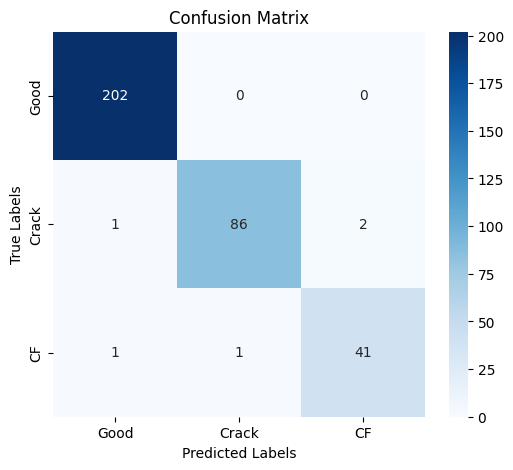

In [16]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

# Display Confusion Matrix
plot_confusion_matrix(y_true, y_pred, class_names)


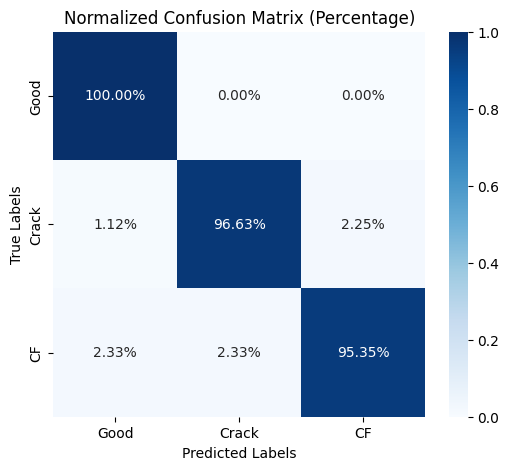

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_normalized_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred, normalize='true')  # Normalize by row (true labels)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Normalized Confusion Matrix (Percentage)")
    plt.show()

# Display Normalized Confusion Matrix
plot_normalized_confusion_matrix(y_true, y_pred, class_names=["Good", "Crack", "CF"])


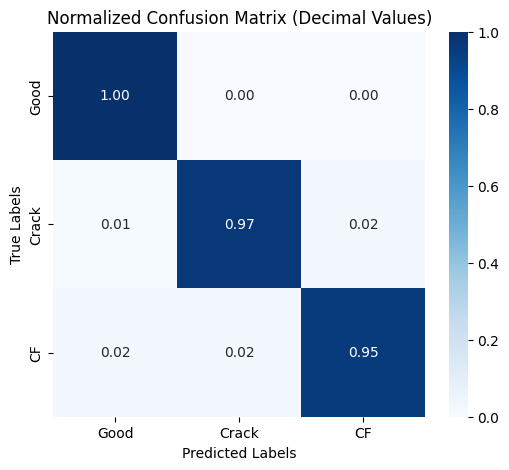

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_normalized_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred, normalize='true')  # Normalize by row (true labels)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)  # Changed fmt=".2f"
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Normalized Confusion Matrix (Decimal Values)")
    plt.show()

# Display Normalized Confusion Matrix in Decimal
plot_normalized_confusion_matrix(y_true, y_pred, class_names=["Good", "Crack", "CF"])


In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Define class names (Adjust if needed)
class_names = ["Good", "Crack", "CF"]


In [20]:
def get_predictions_and_probs(model, dataloader):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities

            all_probs.extend(probs.cpu().numpy())  # Convert to NumPy
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)

# Get true labels and predicted probabilities
y_true, y_probs = get_predictions_and_probs(vit_model, test_loader)

# Convert labels to one-hot encoding for multi-class PR curve
y_true_one_hot = label_binarize(y_true, classes=[0, 1, 2])  # Assuming 3 classes: 0, 1, 2


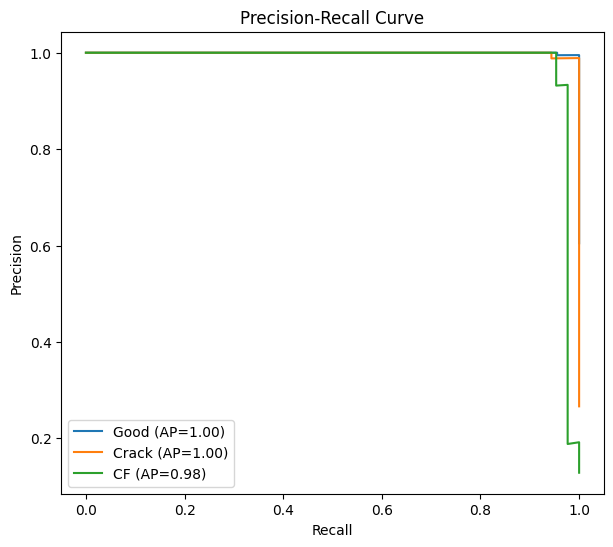

In [29]:
def plot_precision_recall_curve(y_true, y_probs, class_names):
    plt.figure(figsize=(7, 6))

    for i, class_name in enumerate(class_names):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_probs[:, i])
        ap_score = average_precision_score(y_true[:, i], y_probs[:, i])

        plt.plot(recall, precision, label=f"{class_name} (AP={ap_score:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    # plt.grid()
    plt.show()

# Display PR Curve
plot_precision_recall_curve(y_true_one_hot, y_probs, class_names=["Good", "Crack", "CF"])


In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Define class names (Adjust if needed)
class_names = ["Good", "Crack", "CF"]


In [23]:
def get_predictions_and_probs(model, dataloader):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities

            all_probs.extend(probs.cpu().numpy())  # Convert to NumPy
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)

# Get true labels and predicted probabilities
y_true, y_probs = get_predictions_and_probs(vit_model, test_loader)

# Convert labels to one-hot encoding for multi-class ROC-AUC
y_true_one_hot = label_binarize(y_true, classes=[0, 1, 2])  # Assuming 3 classes: 0, 1, 2


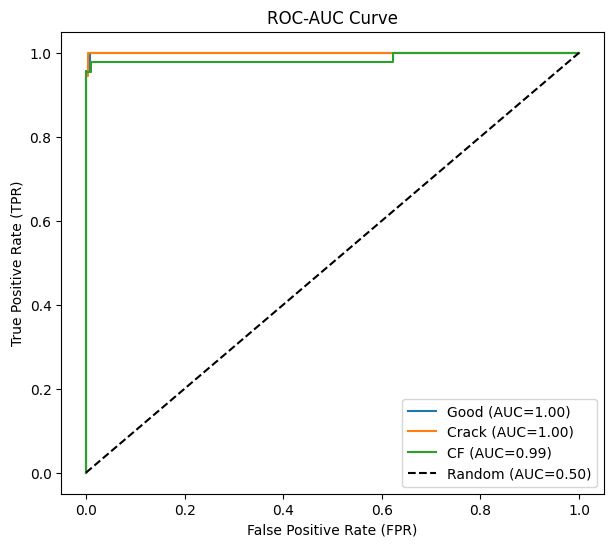

In [24]:
from sklearn.metrics import roc_auc_score

def plot_roc_auc_curve(y_true, y_probs, class_names):
    plt.figure(figsize=(7,6))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC=0.50)")  # Random classifier baseline
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC-AUC Curve")
    plt.legend()
    # plt.grid()
    plt.show()

# Display ROC-AUC Curve
plot_roc_auc_curve(y_true_one_hot, y_probs, class_names=["Good", "Crack", "CF"])


In [25]:
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

# Define the number of classes
num_classes = 3  # Adjust based on your dataset

# Get true labels and predicted probabilities from the model
def get_predictions_and_probs(model, dataloader):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities

            all_probs.extend(probs.cpu().numpy())  # Convert to NumPy
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)

# Extract labels and probabilities
real_labels, pred_probs = get_predictions_and_probs(vit_model, test_loader)

# Convert true labels to one-hot encoding
real_labels_one_hot = label_binarize(real_labels, classes=[0, 1, 2])  # Assuming 3 classes

# Create a DataFrame to store results
df_fpr_tpr = pd.DataFrame()

# Compute FPR, TPR for each class
for i in range(num_classes):
    fpr, tpr, thresholds = roc_curve(real_labels_one_hot[:, i], pred_probs[:, i])
    
    # Store FPR, TPR, and class name
    df_temp = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'class': [i] * len(fpr)})
    df_fpr_tpr = pd.concat([df_fpr_tpr, df_temp], ignore_index=True)

# Save to CSV
df_fpr_tpr.to_csv('C:/Users/101160998/Desktop/Research1/Dataset/fpr_tpr_vit_multiclass.csv', index=False)

print("FPR and TPR values for multi-class ROC saved successfully!")


FPR and TPR values for multi-class ROC saved successfully!


In [26]:
import pandas as pd
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Define the number of classes
num_classes = 3  # Adjust based on your dataset

# Convert true labels to one-hot encoding
real_labels_one_hot = label_binarize(real_labels, classes=[0, 1, 2])  # Assuming 3 classes

# Create a DataFrame to store results
df_pr = pd.DataFrame()

# Compute Precision-Recall for each class
for i in range(num_classes):
    precision, recall, thresholds = precision_recall_curve(real_labels_one_hot[:, i], pred_probs[:, i])
    
    # Store precision, recall, and class name
    df_temp = pd.DataFrame({'precision': precision, 'recall': recall, 'class': [i] * len(precision)})
    df_pr = pd.concat([df_pr, df_temp], ignore_index=True)

# Save to CSV
df_pr.to_csv('C:/Users/101160998/Desktop/Research1/Dataset/pr_vit_multiclass.csv', index=False)

print("Precision-Recall values for multi-class saved successfully!")


Precision-Recall values for multi-class saved successfully!


In [27]:
# fpr, tpr, thresholds = sklearn.metrics.roc_curve(real_labels, pred_probs)
# df_fpr_tpr = {'fpr':fpr, 'tpr':tpr}
# df_fpr_tpr = pd.DataFrame(df_fpr_tpr)
# df_fpr_tpr.to_csv('C:/Users/101160998/Desktop/Research/Data_W/fpr_tpr_vit.csv', index=False)

In [28]:
# precision, recall, _ = sklearn.metrics.precision_recall_curve(real_labels, pred_probs)
# df_pr = {'precision':precision, 'recall':recall}
# df_pr = pd.DataFrame(df_pr)
# df_pr.to_csv('C:/Users/101160998/Desktop/Research/Data_W/pr_vit.csv', index=False)